In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering_invariant import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd
from pygam import LogisticGAM, s
import matplotlib.cm as cm

In [2]:
dfg = pd.read_csv("/Users/judydw/Downloads/rejection_and_effect_gao.csv")
dfgc = pd.read_csv("/Users/judydw/Downloads/rejection_and_effect_gao_clustered.csv")
dfb = pd.read_csv("/Users/judydw/Downloads/rejection_and_effect_barber.csv")
dfr = pd.read_csv("/Users/judydw/Downloads/reject_es.csv")

Fitting tau=0.0
Fitting tau=0.01
Fitting tau=0.05


/Users/judydw/Documents/UMich/Fall 2024/STATS 604/Project1/pythonProject/.venv/lib/python3.9/site-packages/pygam/pygam.py:1149: RuntimeWarning: divide by zero encountered in scalar divide
  r2["explained_deviance"] = 1.0 - full_d.sum() / null_d.sum()
/Users/judydw/Documents/UMich/Fall 2024/STATS 604/Project1/pythonProject/.venv/lib/python3.9/site-packages/pygam/pygam.py:1150: RuntimeWarning: divide by zero encountered in scalar divide
  r2["McFadden"] = full_ll / null_ll
/Users/judydw/Documents/UMich/Fall 2024/STATS 604/Project1/pythonProject/.venv/lib/python3.9/site-packages/pygam/pygam.py:1151: RuntimeWarning: divide by zero encountered in scalar divide
  r2["McFadden_adj"] = 1.0 - (full_ll - self.statistics_["edof"]) / null_ll


Fitting tau=0.1
Fitting tau=0.5
Fitting tau=0.75
Fitting tau=1.0


/Users/judydw/Documents/UMich/Fall 2024/STATS 604/Project1/pythonProject/.venv/lib/python3.9/site-packages/pygam/links.py:148: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Users/judydw/Documents/UMich/Fall 2024/STATS 604/Project1/pythonProject/.venv/lib/python3.9/site-packages/pygam/pygam.py:630: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2


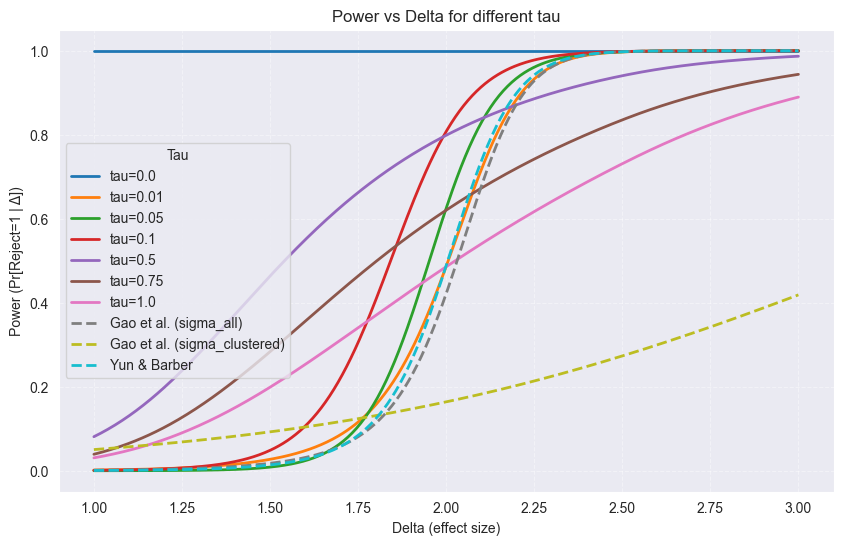

In [4]:
plt.figure(figsize=(10, 6))

for tau, g in dfr.groupby("tau"):
    X = g[["effect_size"]].values
    y = g["reject"].values


    print(f"Fitting tau={tau}")
    gam = LogisticGAM(s(0), n_splines=5, constraints='monotonic_inc').fit(X, y)
    grid = np.linspace(1.0, 3.0, 500)
    power_hat = gam.predict_mu(grid)
    plt.plot(grid, power_hat, lw=2, label=f"tau={tau}")
    
X_g = dfg["effect_size"].values
y_g = dfg["reject"].values
gam = LogisticGAM(s(0), n_splines=5, constraints='monotonic_inc').fit(X_g, y_g)
grid = np.linspace(1.0, 3.0, 500)
power_hat = gam.predict_mu(grid)
plt.plot(grid, power_hat, lw=2,linestyle='--', label="Gao et al. (sigma_all)")

    
X_gc = dfgc["effect_size"].values
y_gc = dfgc["reject"].values
gam = LogisticGAM(s(0), n_splines=15, constraints='monotonic_inc').fit(X_gc, y_gc)
grid = np.linspace(1.0, 3.0, 500)
power_hat = gam.predict_mu(grid)
plt.plot(grid, power_hat, lw=2,linestyle='--', label="Gao et al. (sigma_clustered)")

X_b = dfb["effect_size"].values
y_b = dfb["reject"].values
gam = LogisticGAM(s(0),  n_splines=5,constraints='monotonic_inc').fit(X_b, y_b)
grid = np.linspace(1.0, 3.0, 500)
power_hat = gam.predict_mu(grid)
plt.plot(grid, power_hat, lw=2,linestyle='--', label="Yun & Barber")
plt.xlabel("Delta (effect size)")
plt.ylabel("Power (Pr[Reject=1 | Δ])")
plt.title("Power vs Delta for different tau")
plt.legend(title="Tau")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [47]:
df = pd.read_csv("/Users/judydw/Downloads/hist_counts_combined_equal_False.csv")

In [3]:
result_dict = {}
df = df.drop(df.index[-1])
df = df.astype(int)
f = df.apply(pd.to_numeric, errors='coerce')
result_dict = {}
for column in df.columns:
    non_zero_data = df[column][df[column] != 0].astype(str)
    
    sorted_non_zero_data = dict(sorted(non_zero_data.items(), key=lambda item: int(item[1]), reverse=True))
    
    # 将排序后的结果存储为字典
    result_dict[column] = sorted_non_zero_data

# 打印结果字典
print("\nResulting Dictionary for Each Column (Values as Strings, Sorted in Descending Order):")
for key, value in result_dict.items():
    print(f"{key}: {value}")


Resulting Dictionary for Each Column (Values as Strings, Sorted in Descending Order):
K_value: {30: '30', 29: '29', 28: '28', 27: '27', 26: '26', 25: '25', 24: '24', 23: '23', 22: '22', 21: '21', 20: '20', 19: '19', 18: '18', 17: '17', 16: '16', 15: '15', 14: '14', 13: '13', 12: '12', 11: '11', 10: '10', 9: '9', 8: '8', 7: '7', 6: '6', 5: '5', 4: '4', 3: '3', 2: '2', 1: '1'}
0.0: {3: '100'}
0.005: {3: '98', 4: '2'}
0.01: {3: '100'}
0.05: {3: '100'}
0.1: {3: '90', 6: '3', 12: '2', 4: '1', 5: '1', 8: '1', 9: '1', 20: '1'}
0.5: {17: '9', 13: '7', 16: '7', 9: '6', 15: '6', 21: '6', 11: '5', 14: '5', 18: '5', 22: '5', 23: '5', 19: '4', 8: '3', 10: '3', 12: '3', 24: '3', 25: '3', 2: '2', 4: '2', 5: '2', 20: '2', 26: '2', 27: '2', 1: '1', 3: '1', 28: '1'}
1.0: {1: '11', 20: '10', 24: '10', 23: '8', 21: '7', 17: '6', 22: '6', 18: '5', 14: '4', 25: '4', 8: '3', 13: '3', 15: '3', 16: '3', 19: '3', 26: '3', 27: '3', 7: '2', 10: '2', 12: '2', 9: '1', 11: '1'}


In [23]:
df1 = pd.read_csv("/Users/judydw/Downloads/power_and_recovery.csv")
dfg = pd.read_csv("/Users/judydw/Documents/GitHub/SI_HierarchicalClustering/figs/invariant/power_delta/correct one/power_and_recovery_gao.csv")
dfb = pd.read_csv("/Users/judydw/Documents/GitHub/SI_HierarchicalClustering/figs/invariant/power_delta/correct one/power_and_recovery_barber.csv")
dfr = pd.read_csv("/Users/judydw/Documents/GitHub/SI_HierarchicalClustering/figs/invariant/power_delta/correct one/power_and_recovery.csv")

In [15]:

dfg = pd.read_csv("/Users/judydw/Downloads/rejprop_and_recovery_gao.csv")
dfb = pd.read_csv("/Users/judydw/Downloads/rej_prop_and_recovery_barber.csv")
dfr = pd.read_csv("/Users/judydw/Downloads/rejprop_and_recovery.csv")

In [16]:
df_all = pd.concat([dfg, dfb, dfr], ignore_index=True)

In [14]:
dfr = dfr.rename(columns={"Conditional Power": "Power"})
df1 = df1.rename(columns={"Conditional Power": "Power"})

NameError: name 'df1' is not defined

In [6]:
#dfr.drop(dfr[dfr["Tau"] == 0.01].index, inplace=True)
df_all = pd.concat([dfg, dfb, df1, dfr], ignore_index=True)
tau_list = [0,0.01, 0.05, 0.1,0.5,1]
deltas = [4,6,8,10,12]

NameError: name 'df1' is not defined

In [17]:
df_all

,Tau,Delta,Rejection Proportion,Recovery_Rate,Successful_Trials,Method,Recovery Probability,Successful Trials
0,NaN,0,0.048764,0.998,NaN,Gao,NaN,NaN
1,NaN,2,0.052667,1.000,NaN,Gao,NaN,NaN
2,NaN,4,0.248000,1.000,NaN,Gao,NaN,NaN
3,NaN,6,0.753333,1.000,NaN,Gao,NaN,NaN
4,NaN,8,0.973333,1.000,NaN,Gao,NaN,NaN
5,NaN,10,0.997333,1.000,NaN,Gao,NaN,NaN
6,NaN,0,0.033333,1.000,NaN,Barber,NaN,NaN
7,NaN,2,0.053333,1.000,NaN,Barber,NaN,NaN
8,NaN,4,0.246667,1.000,NaN,Barber,NaN,NaN
9,NaN,6,0.770000,1.000,NaN,Barber,NaN,NaN


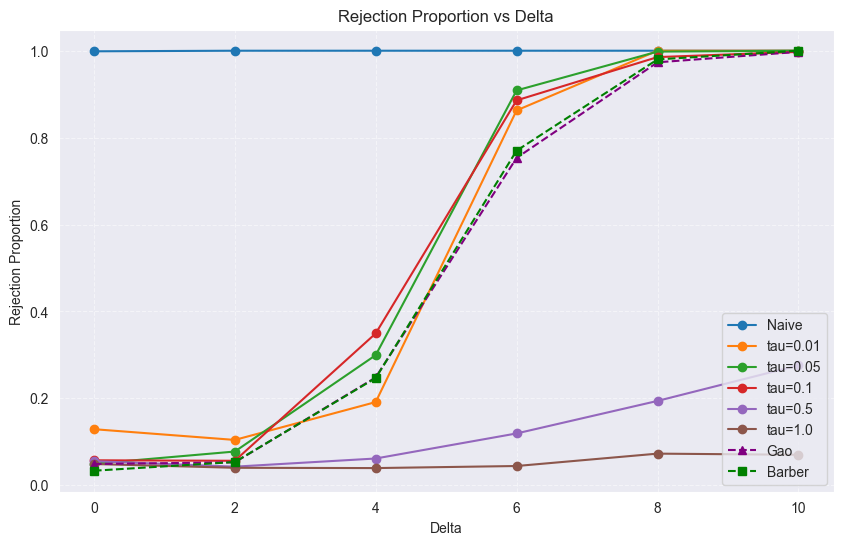

In [18]:
plt.figure(figsize=(10, 6))
for tau, group in df_all[df_all["Method"].isna()].groupby("Tau"):
    label = "Naive" if tau == 0 else f"tau={tau}"
    group = group.sort_values("Delta")
    plt.plot(group["Delta"], group["Rejection Proportion"], marker='o', label=label)


gao = df_all[df_all["Method"] == "Gao"].sort_values("Delta")
plt.plot(gao["Delta"], gao["Rejection Proportion"], marker='^', linestyle='--', color='purple', label='Gao')

barber = df_all[df_all["Method"] == "Barber"].sort_values("Delta")
plt.plot(barber["Delta"], barber["Rejection Proportion"], marker='s', linestyle='--', color='green', label='Barber')

plt.xlabel("Delta")
plt.ylabel("Rejection Proportion")
plt.title("Rejection Proportion vs Delta")
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

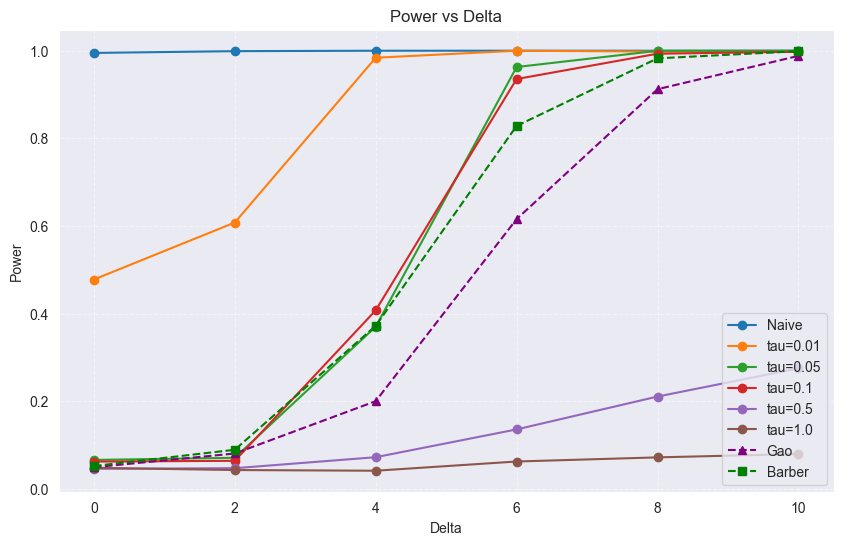

In [26]:
plt.figure(figsize=(10, 6))
for tau, group in df_all[df_all["Method"].isna()].groupby("Tau"):
    label = "Naive" if tau == 0 else f"tau={tau}"
    group = group.sort_values("Delta")
    plt.plot(group["Delta"], group["Power"], marker='o', label=label)


gao = df_all[df_all["Method"] == "Gao"].sort_values("Delta")
plt.plot(gao["Delta"], gao["Power"], marker='^', linestyle='--', color='purple', label='Gao')

barber = df_all[df_all["Method"] == "Barber"].sort_values("Delta")
plt.plot(barber["Delta"], barber["Power"], marker='s', linestyle='--', color='green', label='Barber')

plt.xlabel("Delta")
plt.ylabel("Power")
plt.title("Power vs Delta")
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [67]:
a = [True, False,False]
sum(a) >=1

True

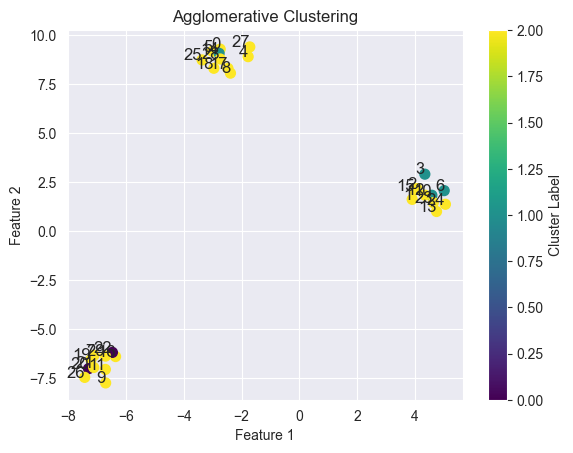

In [12]:
X, y = make_blobs(n_samples=30, centers=3, cluster_std=0.5,random_state=42)

# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=1, n_clusters=3,linkage="complete")
model.fit(dendrogram=True)
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.K_clusters):
    for point_index in node.points:
        cluster_labels[point_index] = idx
    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [5]:
keys = list(model.existing_clusters_log.keys())
clusters = model.existing_clusters_log[keys[-1]]
c1 = model.K_clusters[0]
c2 = model.K_clusters[2]
model.merge_inference_F_random_pair(c1,c2)

NameError: name 'model' is not defined

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal,f
def generate_null_data(n, p, mu, sigma):
    mu = np.array(mu)  # Ensure mu is an array
    cov = (sigma ** 2) * np.eye(p)  # Covariance matrix
    return np.random.multivariate_normal(mu, cov, size=n)

def compute_nu_pair(c1,c2, n):
    # return the projection direction from the given node
    G_1 = np.array(c1.points)
    G_2 = np.array(c2.points)
    n_G1 = len(G_1)
    n_G2 = len(G_2)

    nu = np.zeros(n)

    nu[G_1] += 1 / n_G1
    nu[G_2] -= 1 / n_G2
    return nu

def create_indicator_diagonal_matrix(index_list, n):
    diag = np.zeros(n)
    diag[index_list] = 1
    return np.diag(diag), diag


def naive_p_value(X, K, c1,c2,linkage):
    n = X.shape[0]
    p = X.shape[1]
    model = AgglomerativeClustering(X, tau=0, n_clusters=K, linkage=linkage) #fit non-randomized hierarchical clustering model
    model.fit()
    nu = compute_nu_pair(c1,c2,n).reshape(-1, 1)
    p_node_1 = c1
    p_node_2 = c2
    m = len(p_node_1.points) + len(p_node_2.points)
    if m <= 2:
        return np.nan
    P0 = nu @ nu.T / np.linalg.norm(nu) ** 2
    I1, one1 = create_indicator_diagonal_matrix(p_node_1.points, n)
    I2, one2 = create_indicator_diagonal_matrix(p_node_2.points, n)
    one1 = one1.reshape(-1, 1)
    one2 = one2.reshape(-1, 1)
    P1 = (I1 - one1 @ one1.T / len(p_node_1.points)) + (I2 - one2 @ one2.T / len(p_node_2.points))

    observed_target = (m - 2) * np.linalg.norm(P0 @ X, 'fro') ** 2 / np.linalg.norm(P1 @ X, 'fro') ** 2

    p_value = 1 - f.cdf(observed_target, dfn=p, dfd=(m - 2) * p)
    return p_value

def check_p_value_uniformity(n, p, sigma, K, tau, linkage="complete", num_trials=1000):
    p_values = []
    p_values_n = []
    mu = np.zeros(p)

    while len(p_values_n) < num_trials:
        X = generate_null_data(n, p, mu, sigma)
        model = AgglomerativeClustering(X, tau=tau, n_clusters=K, linkage=linkage)
        model.fit()

        idx1, idx2 = np.random.choice(np.arange(K), size=2, replace=False)
        c1 = model.K_clusters[idx1]
        c2 = model.K_clusters[idx2]
        p_value, obs = model.merge_inference_F_random_pair_grid(c1,c2, grid_width=20, ncoarse=20, ngrid=2000)
        p_value_n = naive_p_value(X, K, c1, c2,linkage)
        if not (np.isnan(p_value) and np.isnan(p_value_n)):
            p_values.append(p_value)
            p_values_n.append(p_value_n)
    p_values = np.array(p_values)
    p_values_n = np.array(p_values_n)

    # Histogram for both p-values
    plt.figure(figsize=(8, 5))
    plt.hist(p_values, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black",
             label="Selection-based p-value")
    plt.hist(p_values_n, bins=20, density=True, alpha=0.5, color="orange", edgecolor="black", label="Naive p-value")
    plt.axhline(1, color='red', linestyle='dashed', linewidth=2, label="Uniform(0,1)")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of P-values Under the Null Hypothesis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.ecdfplot(p_values, color="blue", label="Selection-based p-values")
    sns.ecdfplot(p_values_n, color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("P-value")
    plt.ylabel("ECDF")
    plt.title("Empirical CDF of P-values")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Q-Q Plot for both p-values
    plt.figure(figsize=(8, 5))
    sorted_p_values = np.sort(p_values)
    sorted_p_values_n = np.sort(p_values_n)
    theoretical_quantiles = np.linspace(0, 1, num_trials)

    plt.plot(theoretical_quantiles, sorted_p_values, marker='o', linestyle='', color="blue",
             label="Selection-based p-values")
    plt.plot(theoretical_quantiles, sorted_p_values_n, marker='o', linestyle='', color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


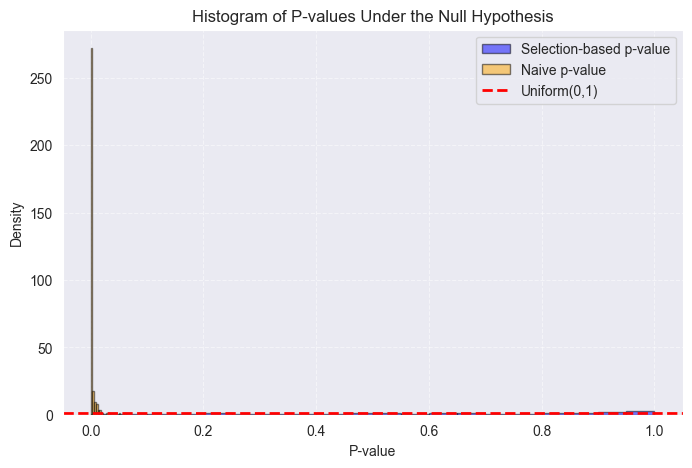

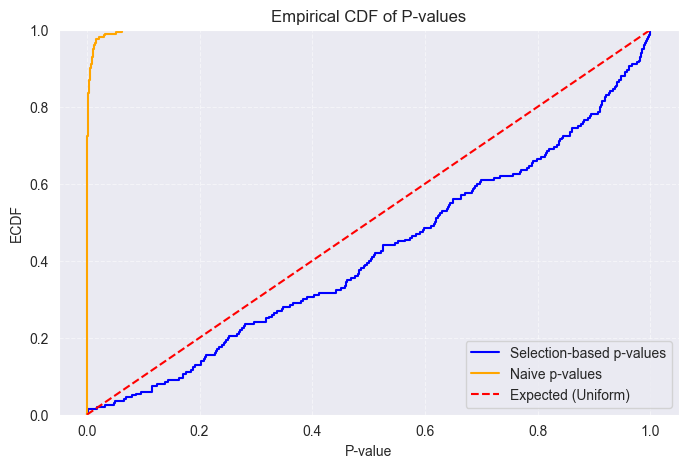

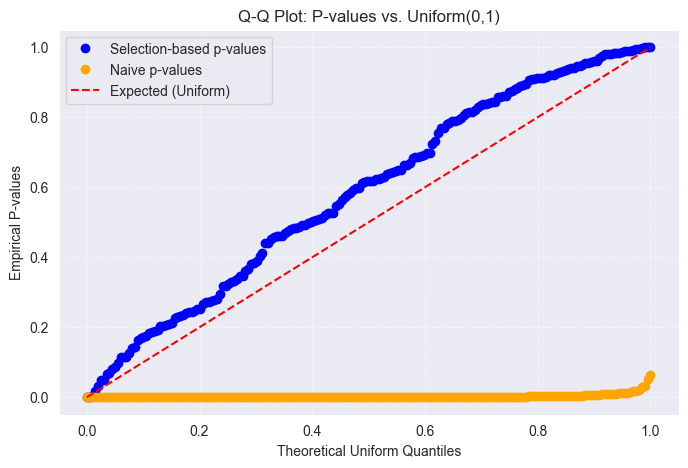

In [5]:
check_p_value_uniformity(30,10,1,3,0.01,"complete", 200)

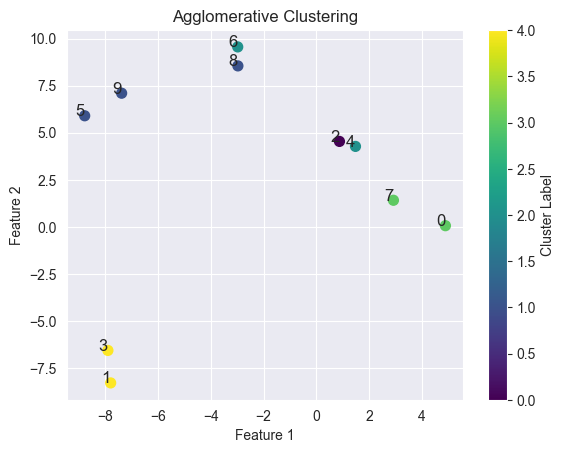

In [6]:
X, y = make_blobs(n_samples=10, centers=5, cluster_std=1,random_state=42)

# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=3, n_clusters=5,linkage="complete")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.K_clusters):
    for point_index in node.points:
        cluster_labels[point_index] = idx
    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

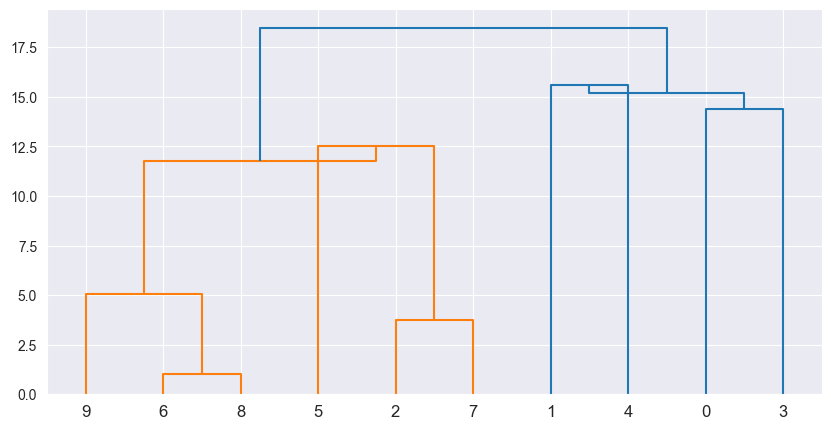

In [7]:
model.plot_dendrogram()

## Plots for Silhouette Scores for different values of  $\tau$
an average silhouette width of over 0.7 is considered to be "strong", a value over 0.5 "reasonable" and over 0.25 "weak"

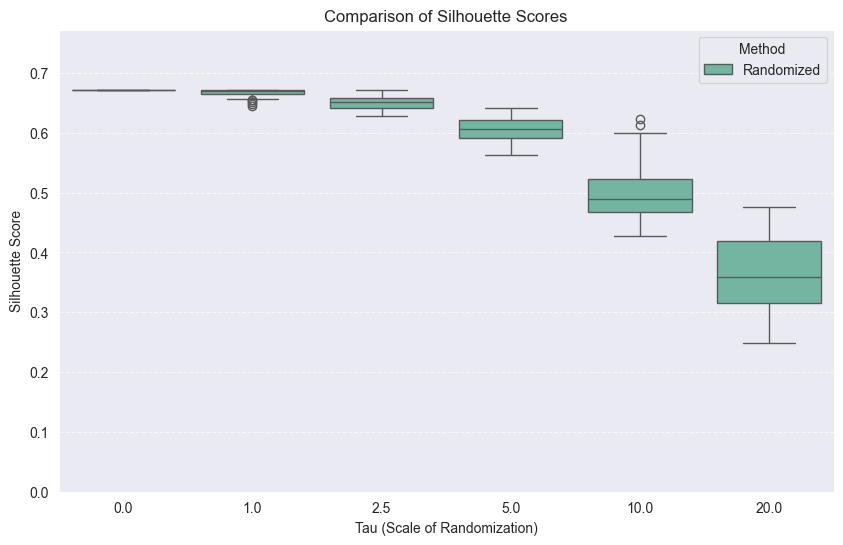

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define a range of tau values
n = 200
tau_values = [0,1,2.5,5,10,20]
n_runs = 50
n_clusters = 5  
# Data collection
results = []

for tau in tau_values:
    for _ in range(n_runs):
        X, y = make_blobs(n_samples=n, centers=5, cluster_std=1,random_state=42)
        # Randomized hierarchical clustering
        randomized_clustering = AgglomerativeClustering(X, n_clusters=n_clusters, tau=tau)
        randomized_clustering.fit()
        randomized_score = randomized_clustering.compute_silhouette_score()
        results.append({'Tau': tau, 'Method': 'Randomized', 'Silhouette Score': randomized_score})

# Convert results to a DataFrame
df = pd.DataFrame(results)

# Create side-by-side boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Tau', y='Silhouette Score', hue='Method', palette='Set2')
plt.title('Comparison of Silhouette Scores')
plt.xlabel('Tau (Scale of Randomization)')
plt.ylabel('Silhouette Score')
plt.legend(title='Method')
y_max = df['Silhouette Score'].max() 
plt.ylim(0, y_max + 0.1) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Plot of within-cluster sum of square
$$
WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2
$$

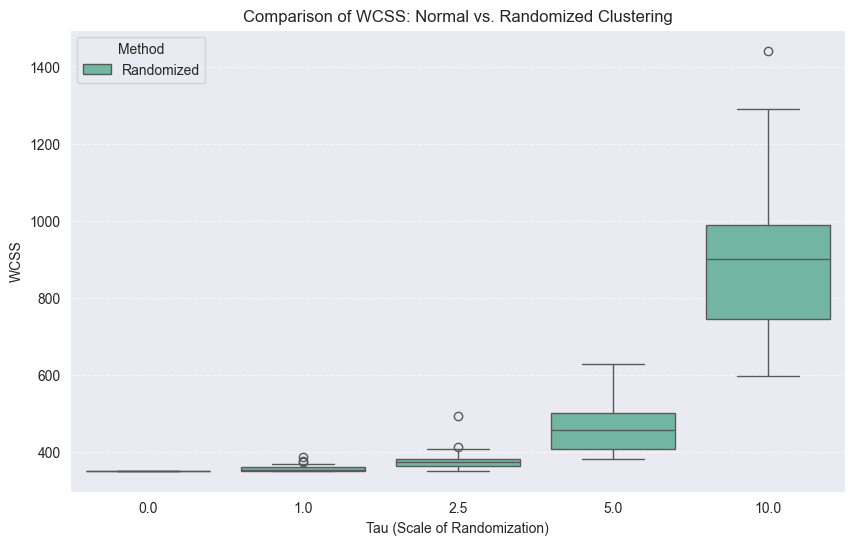

In [18]:
n = 200
tau_values = [0,1,2.5,5,10]
n_runs = 50
n_clusters = 5  
# Data collection
results = []

for tau in tau_values:
    for _ in range(n_runs):
        X, y = make_blobs(n_samples=n, centers=5, cluster_std=1,random_state=42)
        # Randomized hierarchical clustering
        randomized_clustering = AgglomerativeClustering(X, n_clusters=n_clusters, tau=tau)
        randomized_clustering.fit()
        randomized_score = randomized_clustering.compute_wcss()
        results.append({'Tau': tau, 'Method': 'Randomized', 'WCSS': randomized_score})

# Convert results to a DataFrame
df = pd.DataFrame(results)

# Create side-by-side boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Tau', y='WCSS', hue='Method', palette='Set2')
plt.title('Comparison of WCSS: Normal vs. Randomized Clustering')
plt.xlabel('Tau (Scale of Randomization)')
plt.ylabel('WCSS')
plt.legend(title='Method')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

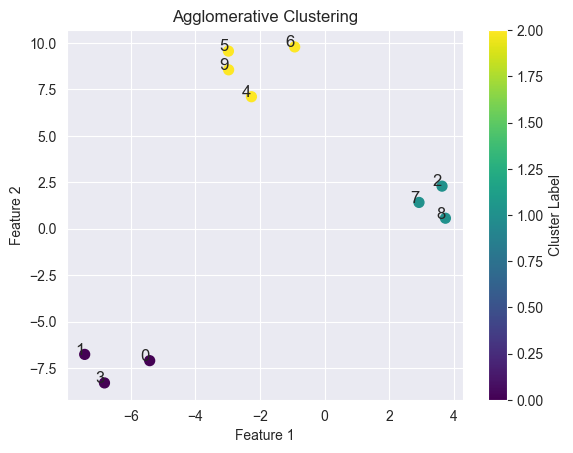

In [2]:
X, y = make_blobs(n_samples=10, centers=3, cluster_std=1,random_state=42)

# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=1, n_clusters=3,linkage="ward")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.cluster_nodes):
    for point_index in node.points:
        cluster_labels[point_index] = idx

    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [3]:
print("Distance Log:")
for key, value in model.distance_log.items():
    print(f"{key}: {value}")

Distance Log:
(ClusterNode(points=[0]), ClusterNode(points=[1])): 2.0380364931244994
(ClusterNode(points=[0]), ClusterNode(points=[2])): 13.037418962158593
(ClusterNode(points=[0]), ClusterNode(points=[3])): 1.8418128827045737
(ClusterNode(points=[0]), ClusterNode(points=[4])): 14.551211837000686
(ClusterNode(points=[0]), ClusterNode(points=[5])): 16.83975525993707
(ClusterNode(points=[0]), ClusterNode(points=[6])): 17.472763390969146
(ClusterNode(points=[0]), ClusterNode(points=[7])): 11.912454405048726
(ClusterNode(points=[0]), ClusterNode(points=[8])): 11.934209188039876
(ClusterNode(points=[0]), ClusterNode(points=[9])): 15.843668027053912
(ClusterNode(points=[1]), ClusterNode(points=[2])): 14.288035244679854
(ClusterNode(points=[1]), ClusterNode(points=[3])): 1.653093983207061
(ClusterNode(points=[1]), ClusterNode(points=[4])): 14.797789518418515
(ClusterNode(points=[1]), ClusterNode(points=[5])): 16.920413362187247
(ClusterNode(points=[1]), ClusterNode(points=[6])): 17.7793395019

In [4]:
print("\nExisting Clusters Log:")
for key, value in model.existing_clusters_log.items():
    print(f"Merge: {key} -> Clusters: {value}")


Existing Clusters Log:
Merge: (ClusterNode(points=[0]), ClusterNode(points=[3])) -> Clusters: [ClusterNode(points=[0]), ClusterNode(points=[1]), ClusterNode(points=[2]), ClusterNode(points=[3]), ClusterNode(points=[4]), ClusterNode(points=[5]), ClusterNode(points=[6]), ClusterNode(points=[7]), ClusterNode(points=[8]), ClusterNode(points=[9])]
Merge: (ClusterNode(points=[1]), ClusterNode(points=[0, 3])) -> Clusters: [ClusterNode(points=[1]), ClusterNode(points=[2]), ClusterNode(points=[4]), ClusterNode(points=[5]), ClusterNode(points=[6]), ClusterNode(points=[7]), ClusterNode(points=[8]), ClusterNode(points=[9]), ClusterNode(points=[0, 3])]
Merge: (ClusterNode(points=[5]), ClusterNode(points=[9])) -> Clusters: [ClusterNode(points=[2]), ClusterNode(points=[4]), ClusterNode(points=[5]), ClusterNode(points=[6]), ClusterNode(points=[7]), ClusterNode(points=[8]), ClusterNode(points=[9]), ClusterNode(points=[1, 0, 3])]
Merge: (ClusterNode(points=[7]), ClusterNode(points=[8])) -> Clusters: [C

In [5]:
print("Randomization Log:")
for key, value in model.randomization_log.items():
    print(f"{key}: {value}")


Randomization Log:
1: {(ClusterNode(points=[0]), ClusterNode(points=[1])): -0.4192074051290811, (ClusterNode(points=[0]), ClusterNode(points=[2])): -0.7935946561435466, (ClusterNode(points=[0]), ClusterNode(points=[3])): -1.2263485822149047, (ClusterNode(points=[0]), ClusterNode(points=[4])): 0.39471829023268545, (ClusterNode(points=[0]), ClusterNode(points=[5])): 1.4496246917224627, (ClusterNode(points=[0]), ClusterNode(points=[6])): 0.3795445036203365, (ClusterNode(points=[0]), ClusterNode(points=[7])): 0.7066616343500404, (ClusterNode(points=[0]), ClusterNode(points=[8])): -1.2548559767210463, (ClusterNode(points=[0]), ClusterNode(points=[9])): 1.00288313673437, (ClusterNode(points=[1]), ClusterNode(points=[2])): -0.8198140245176877, (ClusterNode(points=[1]), ClusterNode(points=[3])): 1.754963101178705, (ClusterNode(points=[1]), ClusterNode(points=[4])): 0.478063237311549, (ClusterNode(points=[1]), ClusterNode(points=[5])): -0.10320642933805017, (ClusterNode(points=[1]), ClusterNode

In [6]:
print(model.final_step)

7


In [7]:
node = model.cluster_nodes[1]
p1 = node.left
p2 = node.right

In [8]:
model.existing_clusters_log.keys()

dict_keys([(ClusterNode(points=[0]), ClusterNode(points=[3])), (ClusterNode(points=[1]), ClusterNode(points=[0, 3])), (ClusterNode(points=[5]), ClusterNode(points=[9])), (ClusterNode(points=[7]), ClusterNode(points=[8])), (ClusterNode(points=[2]), ClusterNode(points=[7, 8])), (ClusterNode(points=[4]), ClusterNode(points=[5, 9])), (ClusterNode(points=[6]), ClusterNode(points=[4, 5, 9]))])

In [9]:
def find_key_index(target_key, dictionary):
    for idx, key in enumerate(dictionary.keys()):
        if key == target_key:
            return idx
    return -1 

find_key_index((p1,p2),model.existing_clusters_log)

4

In [11]:
node

ClusterNode(points=[2, 7, 8])